## Read Bulk Output Files

In [1]:
import xarray as xr
import xugrid as xu
import numpy as np
import matplotlib.pyplot as plt
import os
import gc

In [2]:
parent_dir = '/media/cassandra/Expansion/2026-05-05-Cassandra/'

qtr_file = parent_dir + 'sfincs.nc'
qtr = xr.open_dataset(qtr_file)
mesh2d_nFaces = qtr.mesh2d_nFaces.values

years = np.arange(1990, 2024, 1)

In [ ]:
# Prep empty arrays for model output
zsmax    = np.ndarray((0,len(mesh2d_nFaces)),  dtype=np.dtype('float32'))
timemax  = np.ndarray((0,),                    dtype=np.dtype('datetime64[ns]'))

for year in years:
    print("Reading output from", year)
    t0 = np.datetime64(str(year)   + '-01-01T00:00')
    tf = np.datetime64(str(year+1) + '-01-01T00:00')
    
    map_file = parent_dir + str(year) + '/sfincs_map.nc'
    if not os.path.exists(map_file):
        continue
    smap = xr.open_dataset(map_file)

    # Only use times in the calendar year (dropping spinup time
    maptime = smap.timemax.values
    mapzmax = smap.zsmax.values
    tok = np.logical_and(maptime >= t0, maptime < tf)
    
    timemax = np.concatenate([timemax, maptime[tok]], axis=0)
    zsmax   = np.concatenate([  zsmax, mapzmax[tok]], axis=0)
    print("Adding", len(maptime[tok]), 'values for a final shape of', np.shape(zsmax))
    gc.collect()

### Save to NetCDF

In [5]:
d = { "coords": {"timemax"      : {"dims": "timemax",       "data": timemax},
                 "mesh2d_nFaces": {"dims": "mesh2d_nFaces", "data": mesh2d_nFaces}},
      "attrs": {"title": "2026-05-05-Snohomish-Combined"},
      "dims":  ["timemax", "mesh2d_nFaces"],
      "data_vars": {"zmax" : {"dims": ["timemax", "mesh2d_nFaces"], "data": zsmax}}}
ds = xr.Dataset.from_dict(d)
ds.to_netcdf(parent_dir + 'combined_zsmax.nc')

## Peak Over Threshold Analysis

Discharge events decorrelate after around 3-4 days, so use that to decluster events:

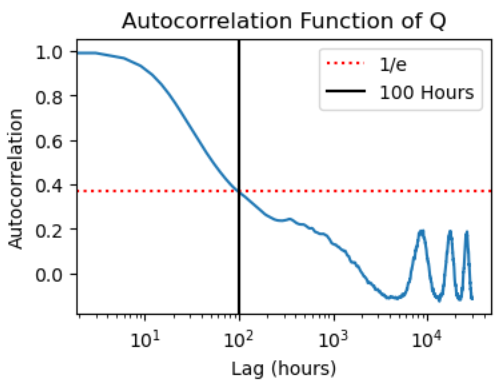

In [28]:
import scipy
import matplotlib.pyplot as plt

# Interval years to search
intervals = [1, 5, 10, 20, 30]

# Empty list for threshold output
thresholds = [[] for interval in intervals]

# Need to think in terms of number of events over the threshold
# For a yearly flood, there are N_YEARS events over the threshold
# Therefore, N = num_events = N_YEARS / INTERVAL
n_years = int(len(timemax)/365)
num_events = [int(np.around(n_years / interval)) for interval in intervals]

# Search distance for peaks: minimum 4 days between peaks
dist = 4 

# For each quadtree cell, detect peaks for each interval
print("Computing Peak Over Threshold Statistics")

# Progress bar
for j in range(len(mesh2d_nFaces)):
    if j % 10000 == 0:
        print('_',end='')
print('')
for j in range(len(mesh2d_nFaces)):
    if j % 10000 == 0:
        print('.',end='')

    # Search for peaks within 4 days -- 
    # 4 days is based on decorrelation lengthscale of discharge boundary time series...
    peaks, _ = scipy.signal.find_peaks(zsmax[:,j], distance=dist)

    # If no peaks, skip (add nans)
    if len(peaks) < 0:
        for i in range(len(intervals)):
            thresholds[i].append(np.nan)

    # Otherwise, look at the order of the peaks
    else:
        peakvals = zsmax[peaks,j]
        order = np.argsort(peakvals)

        # For each interval (1 year, 5 years, 10 years, etc)...
        for i in range(len(intervals)):

            
            N = num_events[i]

            # If there are fewer peaks than the associated number of events (n years / interval)
            # Then skip (add nans)
            if len(peakvals) < N:
                thresholds[i].append(np.nan)

            # Otherwise navigate to the Nth largest event, 
            # where N is the number of events to be above the threshold...
            else:
                thresholds[i].append(peakvals[order[-1 * N]])

thresholds = np.array(thresholds)

___________________________
...........................

### Save as NetCDF

In [30]:
d = { "coords": {"mesh2d_nFaces" : {"dims": "mesh2d_nFaces", "data": mesh2d_nFaces},
                 "years_interval": {"dims": "years_interval","data": intervals}},
      "attrs": {"title": "2026-05-05-Snohomish-zsmax-intervals"},
      "dims":  ["years_interval", "mesh2d_nFaces"],
      "data_vars": {"zsmax" : {"dims": ["years_interval", "mesh2d_nFaces"], "data": thresholds}}}
ds = xr.Dataset.from_dict(d)
ds.to_netcdf(parent_dir + 'zsmax_thresholds.nc')

### XUGrid Plot Test

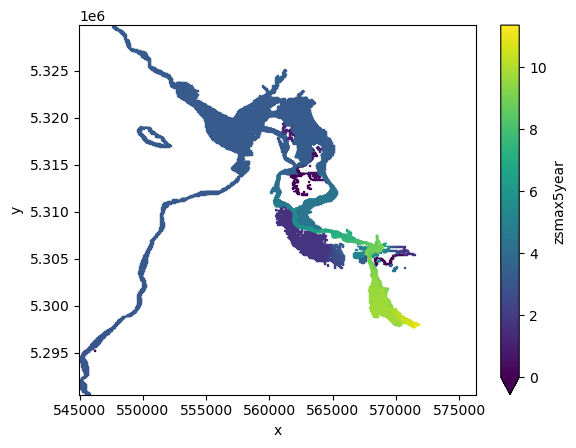

In [38]:
import xugrid as xu

x_qtr = xu.load_dataset(qtr_file)

x_qtr['zsmax1year']    = (('mesh2d_nFaces'), ds.zsmax[0].values)
x_qtr['zsmax5year']    = (('mesh2d_nFaces'), ds.zsmax[1].values)
x_qtr['zsmax10year']    = (('mesh2d_nFaces'), ds.zsmax[2].values)
x_qtr['zsmax20year']    = (('mesh2d_nFaces'), ds.zsmax[3].values)
x_qtr['zsmax30year']    = (('mesh2d_nFaces'), ds.zsmax[4].values)

x_qtr.zsmax5year.ugrid.plot(vmin=0)

### Downscale

In [42]:
import rasterio
from rasterio.windows import Window
from rasterio.features import shapes
from rasterio.windows import transform as window_transform
from rasterio.transform import xy

import numpy as np
import geopandas as gpd
import xarray as xr
import gc

from shapely.geometry import shape

In [48]:
# DEM Info
DEM_tif = "/home/cassandra/Data/Snoh_DEM_composite/Snohomish_MosaicDEM_modded.tif"
bdx, bdy = 1, 1
window_size = 8*1024

# Get the grid z minimum from the subgrid table
sbg_file = parent_dir + 'sfincs_subgrid.nc'
sbg = xr.open_dataset(sbg_file)
zmin = sbg.z_zmin.values

# Get grid info from the quadtree file
qtr_file = parent_dir + 'sfincs.nc'
qtr = xr.open_dataset(qtr_file)

# Load quadtree grid data
bx = qtr.mesh2d_node_x.values
by = qtr.mesh2d_node_y.values
i = qtr.mesh2d_face_nodes.values.astype(int)
lev = qtr.level.values
# Get the grid spacing
qdx = qtr.dx / (2** (lev - 1))
qdy = qtr.dy / (2** (lev - 1))
# Get the corners
x0, y0 = [], []
for j in range(len(i)):
    x0.append(bx[i[j][0]])
    y0.append(by[i[j][0]])
x0 = np.array(x0)
y0 = np.array(y0)
# Get the centers
xc, yc = x0 + qdx/2, y0 + qdy/2

/tmp/ipykernel_38471/949521650.py:13: RuntimeWarning: invalid value encountered in cast
  i = qtr.mesh2d_face_nodes.values.astype(int)


In [ ]:
# For each return interval...
for zsmax, year in zip(ds.zsmax.values, ds.years_interval.values):
    
    # Nan out dry cells
    zsmax[zsmax <= zmin] = np.nan

    # Set out path
    out_tif = parent_dir + str(year) + 'year_hmax.tif'
    print('\n' + out_tif)

    # Open the DEM...
    with rasterio.open(DEM_tif) as src:
        profile = src.profile.copy()
        crs = src.crs

        # Open the output geotiff, copy DEM metadata
        with rasterio.open(out_tif, 'w', **profile) as dst:
            
            # Iterate over windows
            for wyi in range(0, src.height, int(window_size)):

                # progress bar
                print('')
                print("Chunk", int(wyi/window_size)+1, 'of', int(src.height/window_size)+1)
                for wxi in range(0, src.width, int(window_size)):
                    print('_',end='')
                print('')
                for wxi in range(0, src.width, int(window_size)):
                    print('.',end='')

                    # Window and get data
                    w = Window(wxi, wyi,
                               min(window_size, src.width - wxi),
                               min(window_size, src.height - wyi))
                    zb = src.read(window=w)
                    
                    # Read x, y - note, that this assumes the DEM is not rotated 
                    # relative to model coordinate system
                    rows = np.arange(w.height)
                    cols = np.arange(w.width)
                    # Compute x coordinates (center of each column)
                    win_transform = src.window_transform(w)
                    x, _ = xy(win_transform, 0 * np.ones_like(cols), cols, offset='center')
                    # Compute y coordinates (center of each row)
                    _, y = xy(win_transform, rows, 0 * np.ones_like(rows), offset='center')
                    x = np.array(x)
                    y = np.array(y)
                    
                    # For each quadtree grid cell, locate and assign the relevant bathy indices (point from bathy --> quadtree)
                    qi = np.int64(list(range(len(qtr.mesh2d_nFaces))))
                    xi0 = np.int64((x0 - x[0]) / bdx)
                    yi0t = np.int64((y0 - y[-1]) / bdy)
                    xif = np.int64((x0 + qdx - x[0]) / bdx)
                    yift = np.int64((y0 + qdy - y[-1]) / bdy)
                    # flip y axis... I think...
                    yif = -1 * yi0t + len(y) 
                    yi0 = -1 * yift + len(y)
                    
                    # Check what intersects the area of interest -- full quadtree cells only
                    qok = np.logical_and(np.logical_and(xif >= 0, xi0 < len(x)),
                                         np.logical_and(yif >= 0, yi0 < len(y)))
                    # and non-nan values only
                    qok = np.logical_and(qok, ~np.isnan(zsmax))
                    
                    # Access model output
                    flood_depth = np.zeros(zb.shape)*np.nan
                    for i in qi[qok]:
                        for xi in range(xi0[i],xif[i]):
                            if xi >= len(x) or xi < 0:
                                continue
                            for yi in range(yi0[i], yif[i]):
                                if yi >= len(y) or yi < 0:
                                    continue
                                flood_depth[0,yi,xi] = zsmax[i] - zb[0,yi,xi]
                    flood_depth[flood_depth < 0.01] = np.nan
                    
                    # Write to new geotif
                    dst.write(flood_depth, window=w)
                    # collect to try to keep memory leaks under control
                    gc.collect()

### Flood Extent Polygons

In [51]:
def tiff_to_poly(tiff_file, poly_file, cutoff_depth = 0.01, chunk_size=5*1024):
    geometries = []
    with rasterio.open(tiff_file) as src:
        crs = src.crs
        print('chunk loading & finding flood polys for ' + tiff_file + '...')
        print('Progress bar:')
        for row_off in range(0, src.height, chunk_size):
            print('_', end='')
        print('')
        for row_off in range(0, src.height, chunk_size):
            print('.', end='')
            for col_off in range(0, src.width, chunk_size):
                window = Window(col_off=col_off, row_off=row_off,
                                width=min(chunk_size, src.width - col_off),
                                height=min(chunk_size, src.height - row_off))
                data = src.read(1, window=window)
                if np.all(np.isnan(data)):
                    continue
                mask = data >= cutoff_depth
                if not np.any(mask):
                    continue
                win_transform = window_transform(window, src.transform)
                for geom, value in shapes(mask.astype(np.uint8), mask=mask, transform=win_transform):
                    if value == 1:
                        geometries.append(shape(geom))
    print('')
    print('filtering...')
    gdf = gpd.GeoDataFrame(geometry=geometries,crs=crs)
    print('merging...')
    merged = gdf.geometry.union_all()
    merged_gdf = gpd.GeoDataFrame(geometry=[merged], crs=gdf.crs)
    print('separating islands...')
    merged_gdf = merged_gdf.explode(index_parts=False).reset_index(drop=True)
    print('saving to ' + poly_file + '...')
    merged_gdf.to_file(poly_file, driver='GeoJSON')
    print("Done!")
    print("")

In [52]:
# For each return interval...
for year in ds.years_interval.values:
    out_tif = parent_dir + str(year) + 'year_hmax.tif'
    out_poly = parent_dir + str(year) + 'year_hmax.geojson'
    tiff_to_poly(out_tif, out_poly)

chunk loading & finding flood polys for /media/cassandra/Expansion/2026-05-05-Cassandra/1year_hmax.tif...
Progress bar:
_______
.......
filtering...
merging...
separating islands...
saving to /media/cassandra/Expansion/2026-05-05-Cassandra/1year_hmax.geojson...
Done!

chunk loading & finding flood polys for /media/cassandra/Expansion/2026-05-05-Cassandra/5year_hmax.tif...
Progress bar:
_______
.......
filtering...
merging...
separating islands...
saving to /media/cassandra/Expansion/2026-05-05-Cassandra/5year_hmax.geojson...
Done!

chunk loading & finding flood polys for /media/cassandra/Expansion/2026-05-05-Cassandra/10year_hmax.tif...
Progress bar:
_______
.......
filtering...
merging...
separating islands...
saving to /media/cassandra/Expansion/2026-05-05-Cassandra/10year_hmax.geojson...
Done!

chunk loading & finding flood polys for /media/cassandra/Expansion/2026-05-05-Cassandra/20year_hmax.tif...
Progress bar:
_______
.......
filtering...
merging...
separating islands...
saving t